This notebook has been inspired from [Tabular_SARSA](https://colab.research.google.com/github/probml/pyprobml/blob/master/notebooks/book2/35/supplementary/Tabular_SARSA.ipynb) by Amouzgar & Murphy and [SARSA Reinforcement Learning](https://www.geeksforgeeks.org/sarsa-reinforcement-learning/) by Alinda

# SARSA

In this notebook, we will implement SARSA Reinforcement learning

---

algorithm for Frozen Lake Environment.

## Frozen Lake

Frozen lake is a toy text environment involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. <br>

We can also set the lake to be slippery so that the agent does not always move in the intended direction. \but here, we will only look at the non-slippery case. But you are welcome to try the slippery one.<br>

You can read more about the environment [here](https://gymnasium.farama.org/environments/toy_text/frozen_lake/).

![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)


## OpenAI Gym

[OpenAI Gym](https://www.gymlibrary.dev/) is a toolkit for developing and comparing reinforcement learning (RL) algorithms. It consists of a growing suite of environments (from simulated robots to Atari games), and a site for comparing and reproducing results. OpenAI Gym provides a diverse suite of environments that range from easy to difficult and involve many different kinds of data.

Creating and Interacting with gym environments is very simple.

```
import gym
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=42)

for _ in range(1000):
    action = env.action_space.sample()
    observation, reward, done, truncated, info = env.step(action)

    if terminated or truncated:
        observation, info = env.reset()
env.close()
```

Following are the definitions of some common terminologies used.

**Reset:** Resets the environment to an initial state and returns the initial observation. <br>
**Step:** Run one timestep of the environment's dynamics.<br>
**Observation:** The observed state of the environment.<br>
**Action:** An action provided by the agent.<br>
**Reward:** The amount of reward returned as a result of taking the action.<br>
**Terminated:** Whether a terminal state (as defined under the MDP of the task) is reached.<br>
**Truncated:** Whether a truncation condition outside the scope of the MDP is satisfied. Typically a timelimit, but could also be used to indicate agent physically going out of bounds.<br>
**Info:** This contains auxiliary diagnostic information (helpful for debugging, learning, and logging).<br>
**Action Space:** This attribute gives the format of valid actions. It is of datatype Space provided by Gym. For example, if the action space is of type Discrete and gives the value Discrete(2), this means there are two valid discrete actions: 0 & 1.<br>
**Observation:** This attribute gives the format of valid observations. It is of datatype Space provided by Gym. For example, if the observation space is of type Box and the shape of the object is (4,), this denotes a valid observation will be an array of 4 numbers.<br>

Note: Previously, `terminated` and `truncated` used to be merged under one variable `done`. <br>


We will use OpenAI Gym for Frozen Lake environment.

## On-Policy vs. Off-Policy Algorithms

**On Policy:** In this, the learning agent learns the value function according to the current action derived from the policy currently being used.


**Off Policy:** In this, the learning agent learns the value function according to the action derived from another policy.

## SARSA Algorithm

SARSA algorithm is a slight variation of the Q-Learning algorithm. Q-Learning technique is an Off-Policy technique and uses the greedy approach to learn the Q-value. SARSA technique, on the other hand, is an On-Policy and uses the action performed by the current policy to learn the Q-value.

**Q-Learning:**
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left [ r(s,a) + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t) \right ]$$

**SARSA:**
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left [ r(s,a) + \gamma Q(s_{t+1},a_{t+1}) - Q(s_t,a_t) \right ]$$

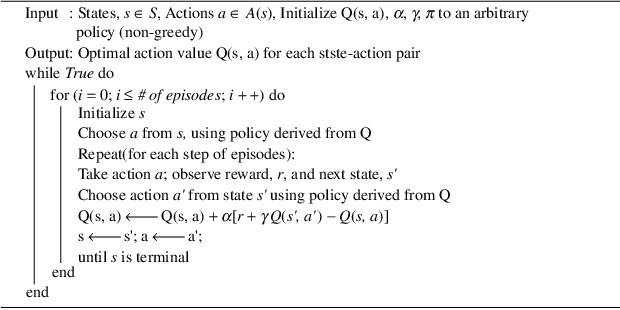

[Image Source](https://www.researchgate.net/publication/228410947_Adaptive_learning_by_a_target-tracking_system)

### Q-Table

Now, we need to create Q-table. A Q table helps us find the best action for each state. It gives us the Q-value for each state-action pair.<br>

To know how much rows (states) and columns (actions) we need, we need to calculate the action_size and the state_size. OpenAI Gym provides us a way to do that.

### Exploration vs Exploitation

Notice that SARSA only learns about the states and actions it visits. What if an optimal state remains unvisited due to not being explored. The agent should sometimes pick suboptimal actions in order to visit new states and actions. <br>

A simple strategy is to use an $\epsilon$-greedy policy. According to this policy, the agent takes a random action with epsilon probability. The value of epsilon is high at the start of training and low towards the end. So, the agent explores more at the start and then exploit the learned policy more at the end.

### Hyperparameters

### Training

### Visualization